# Radial Basis Function Neural Network for predicting LogP values

This script serves to predict LogP values using a classic neural network and a radial basis function based neural network (RBFNN)
There are 5 parts to this script:
1. Data visualisation and processing
1. Implementing a classic neural network
2. Tuning parameters of the classic neural network
3. Implementing a RBFNN
4. Tuning parameters of the classic neural network
5. Conclusion

# Data Visualisation and Processing

In [376]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [377]:
names = ['Chemical Structure','Log P']
lp1 = pd.read_csv('logP_dataset.csv', names=names)


In [378]:
lp1.info()

<class 'pandas.DataFrame'>
RangeIndex: 14610 entries, 0 to 14609
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Chemical Structure  14610 non-null  str    
 1   Log P               14610 non-null  float64
dtypes: float64(1), str(1)
memory usage: 228.4 KB


In [379]:
#check contain NaN or not
#np.isnan(lp1.any())


In [380]:
#check if contain infinity value or not
#np.isfinite(lp1.all())

In [381]:
lp1.describe()

,Log P
count,14610.000000
mean,0.998665
std,1.300486
min,-3.600000
25%,0.100000
50%,1.000000
75%,1.800000
max,6.200000


In [382]:
import rdkit 
from rdkit import Chem
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit.Chem.EState import Fingerprinter

In [383]:
#a function to calculate molecular descriptors for an input mol
def get_fps(mol):
    calc=MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
    ds = np.asarray(calc.CalcDescriptors(mol))
    
    # arr=Fingerprinter.FingerprintMol(mol)[0]
    
    return ds

In [384]:
# Call RDKit functions to generate molecule descriptors for the data set.
lp1['molecule'] = lp1['Chemical Structure'].apply(Chem.MolFromSmiles)
lp1['Descriptors'] = lp1['molecule'].apply(get_fps)

lp1.head()

,Chemical Structure,Log P,molecule,Descriptors
0,C[C@H]([C@@H](C)Cl)Cl,2.3,<rdkit.Chem.rdchem.Mol object at 0x13eeb71b0>,"[5.48070987654321, 5.48070987654321, 0.0895061..."
1,C(C=CBr)N,0.3,<rdkit.Chem.rdchem.Mol object at 0x13eeb68f0>,"[5.022222222222222, 5.022222222222222, 0.61631..."
2,CCC(CO)Br,1.3,<rdkit.Chem.rdchem.Mol object at 0x13eeb6960>,"[8.28789351851852, 8.28789351851852, 0.2465277..."
3,[13CH3][13CH2][13CH2][13CH2][13CH2][13CH2]O,2.0,<rdkit.Chem.rdchem.Mol object at 0x13eeb6880>,"[8.292882653061223, 8.292882653061223, 0.36111..."
4,CCCOCCP,0.6,<rdkit.Chem.rdchem.Mol object at 0x13eeb67a0>,"[5.111111111111112, 5.111111111111112, 0.88740..."


In [385]:
descriptors = [x[0] for x in Descriptors._descList]
descriptors

['MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA5',
 'SMR_VSA6',


In [386]:
#creating the descriptor and logP dataframe

desc_data = np.array(list(lp1['Descriptors']))
logP = lp1['Log P']

In [387]:
desc_data.shape

(14610, 217)

In [388]:
df = pd.DataFrame(desc_data, columns=descriptors)
full_df = pd.concat([df, logP], axis=1)
full_df

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,Log P
0,5.480710,5.480710,0.089506,0.089506,0.473544,20.000000,127.014000,118.950000,126.000306,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.3
1,5.022222,5.022222,0.616319,0.616319,0.567701,10.000000,135.992000,129.944000,134.968361,30.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3
2,8.287894,8.287894,0.246528,0.246528,0.589679,14.500000,153.019000,143.947000,151.983677,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.3
3,8.292883,8.292883,0.361111,0.361111,0.427695,9.428571,108.131129,94.019129,108.124594,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0
4,5.111111,5.111111,0.887407,0.887407,0.400945,9.428571,120.132000,107.028000,120.070402,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14605,3.438657,3.438657,0.664352,0.664352,0.571946,14.500000,169.087000,160.015000,167.960833,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.7
14606,8.319444,8.319444,0.774306,-2.685764,0.383258,21.833333,94.106204,84.030000,94.059898,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.8
14607,2.958333,2.958333,0.537037,0.537037,0.468365,10.000000,88.154000,76.058000,88.100048,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4
14608,2.402778,2.402778,0.921296,0.921296,0.419974,25.500000,83.154000,72.066000,83.086075,35.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.4


In [389]:
#dropping NAN values

df_drop_na = full_df.dropna(axis=0)
df_drop_na

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,Log P
0,5.480710,5.480710,0.089506,0.089506,0.473544,20.000000,127.014000,118.950000,126.000306,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.3
1,5.022222,5.022222,0.616319,0.616319,0.567701,10.000000,135.992000,129.944000,134.968361,30.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3
2,8.287894,8.287894,0.246528,0.246528,0.589679,14.500000,153.019000,143.947000,151.983677,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.3
3,8.292883,8.292883,0.361111,0.361111,0.427695,9.428571,108.131129,94.019129,108.124594,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0
4,5.111111,5.111111,0.887407,0.887407,0.400945,9.428571,120.132000,107.028000,120.070402,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14605,3.438657,3.438657,0.664352,0.664352,0.571946,14.500000,169.087000,160.015000,167.960833,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.7
14606,8.319444,8.319444,0.774306,-2.685764,0.383258,21.833333,94.106204,84.030000,94.059898,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.8
14607,2.958333,2.958333,0.537037,0.537037,0.468365,10.000000,88.154000,76.058000,88.100048,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4
14608,2.402778,2.402778,0.921296,0.921296,0.419974,25.500000,83.154000,72.066000,83.086075,35.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.4


In [390]:
df_drop_na.isna().sum().sum()

np.int64(0)

In [391]:
#correlation matrix

coeff = df_drop_na.corr()
coeff

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,Log P
MaxAbsEStateIndex,1.000000,1.000000,-0.265225,-0.648151,0.036078,0.055770,-0.138934,-0.121660,-0.139165,0.012345,...,NaN,NaN,-0.009966,-0.008615,-0.014757,NaN,-0.011072,-0.066798,NaN,-0.184726
MaxEStateIndex,1.000000,1.000000,-0.265225,-0.648151,0.036078,0.055770,-0.138934,-0.121660,-0.139165,0.012345,...,NaN,NaN,-0.009966,-0.008615,-0.014757,NaN,-0.011072,-0.066798,NaN,-0.184726
MinAbsEStateIndex,-0.265225,-0.265225,1.000000,-0.046015,-0.051476,0.165613,0.009788,0.010228,0.010039,-0.158903,...,NaN,NaN,0.042034,-0.006611,0.022575,NaN,0.011482,0.065543,NaN,0.142711
MinEStateIndex,-0.648151,-0.648151,-0.046015,1.000000,-0.066723,-0.399605,0.089724,0.088666,0.090589,0.018033,...,NaN,NaN,0.026843,0.002949,0.025131,NaN,0.020165,0.139189,NaN,0.107322
qed,0.036078,0.036078,-0.051476,-0.066723,1.000000,0.124756,0.191335,0.162781,0.189165,0.199980,...,NaN,NaN,-0.037082,-0.003551,0.005838,NaN,0.004102,0.009263,NaN,0.342066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fr_thiocyan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fr_thiophene,-0.011072,-0.011072,0.011482,0.020165,0.004102,-0.007161,-0.025634,-0.022401,-0.025640,-0.046053,...,NaN,NaN,-0.001027,-0.000342,-0.000802,NaN,1.000000,-0.007834,NaN,0.018235
fr_unbrch_alkane,-0.066798,-0.066798,0.065543,0.139189,0.009263,-0.105461,0.000353,-0.030111,0.001041,0.325893,...,NaN,NaN,-0.009597,-0.003197,-0.007500,NaN,-0.007834,1.000000,NaN,0.321662
fr_urea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [392]:
#finding which features have a correlation coefficient > 0.25

thres = 0.25
greater_than_thres =  coeff.loc[(coeff['Log P'] >= thres)]
greater_than_thres_list = [row for row in greater_than_thres['Log P'].index]
greater_than_thres_list

['qed',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'MinPartialCharge',
 'BCUT2D_MWHI',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'Chi0v',
 'Chi1v',
 'HallKierAlpha',
 'LabuteASA',
 'PEOE_VSA6',
 'SMR_VSA10',
 'SMR_VSA5',
 'SlogP_VSA12',
 'SlogP_VSA4',
 'SlogP_VSA5',
 'EState_VSA5',
 'EState_VSA8',
 'VSA_EState10',
 'VSA_EState7',
 'VSA_EState8',
 'MolLogP',
 'MolMR',
 'fr_alkyl_halide',
 'fr_halogen',
 'fr_unbrch_alkane',
 'Log P']

In [393]:
#finding which features have a correlation coefficient < -0.25

smaller_than_neg_thres =  coeff.loc[(coeff['Log P'] <= -thres)]
smaller_than_neg_thres_list = [row for row in smaller_than_neg_thres['Log P'].index]
smaller_than_neg_thres_list


['MaxAbsPartialCharge',
 'PEOE_VSA1',
 'SMR_VSA1',
 'SMR_VSA3',
 'SMR_VSA6',
 'SlogP_VSA1',
 'SlogP_VSA2',
 'TPSA',
 'VSA_EState3',
 'VSA_EState4',
 'NHOHCount',
 'NOCount',
 'NumHAcceptors',
 'NumHDonors',
 'NumHeteroatoms',
 'fr_Al_OH',
 'fr_Al_OH_noTert',
 'fr_NH1',
 'fr_NH2']

In [394]:
high_corr_features = greater_than_thres_list + smaller_than_neg_thres_list
high_corr_features.remove('Log P')
high_corr_features.remove('MolLogP')
high_corr_features

#These features are highly correlated to logP or inversely related to logP

['qed',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'MinPartialCharge',
 'BCUT2D_MWHI',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'Chi0v',
 'Chi1v',
 'HallKierAlpha',
 'LabuteASA',
 'PEOE_VSA6',
 'SMR_VSA10',
 'SMR_VSA5',
 'SlogP_VSA12',
 'SlogP_VSA4',
 'SlogP_VSA5',
 'EState_VSA5',
 'EState_VSA8',
 'VSA_EState10',
 'VSA_EState7',
 'VSA_EState8',
 'MolMR',
 'fr_alkyl_halide',
 'fr_halogen',
 'fr_unbrch_alkane',
 'MaxAbsPartialCharge',
 'PEOE_VSA1',
 'SMR_VSA1',
 'SMR_VSA3',
 'SMR_VSA6',
 'SlogP_VSA1',
 'SlogP_VSA2',
 'TPSA',
 'VSA_EState3',
 'VSA_EState4',
 'NHOHCount',
 'NOCount',
 'NumHAcceptors',
 'NumHDonors',
 'NumHeteroatoms',
 'fr_Al_OH',
 'fr_Al_OH_noTert',
 'fr_NH1',
 'fr_NH2']

In [395]:
X = df_drop_na[high_corr_features].to_numpy()
X.shape


(14329, 46)

In [396]:
y = df_drop_na['Log P'].to_numpy()
y.shape

(14329,)

In [397]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [398]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
st = StandardScaler()
X_train, X_test = st.fit_transform(x_train), st.transform(x_test)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10746, 46)
(3583, 46)
(10746,)
(3583,)


# Using a classic neural network

In [399]:
from keras import Sequential, Input
from sklearn.preprocessing import StandardScaler
from keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(len(X_train[0]),)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
  ])

/Users/xianliangchu/Desktop/CM4044 Mini Project II Group 8/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [400]:

model.compile(
    loss='mean_squared_error', 
    optimizer='adam', 
    metrics=['mean_squared_error']
)
# train the model
history = model.fit(
    X_train,
    y_train,
    epochs=10, 
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5912 - mean_squared_error: 0.5912 - val_loss: 0.2273 - val_mean_squared_error: 0.2273
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - loss: 0.3129 - mean_squared_error: 0.3129 - val_loss: 0.1787 - val_mean_squared_error: 0.1787
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - loss: 0.2493 - mean_squared_error: 0.2493 - val_loss: 0.1571 - val_mean_squared_error: 0.1571
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step - loss: 0.2182 - mean_squared_error: 0.2182 - val_loss: 0.1464 - val_mean_squared_error: 0.1464
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - loss: 0.1990 - mean_squared_error: 0.1990 - val_loss: 0.1463 - val_mean_squared_error: 0.1463
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - loss: 0.1781 - mean_squared_error: 0.1781 - val_loss: 0.1351 - val_mean_squared_error: 0.1351
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - loss: 0.1666 - mean_squared_error: 0.1666 - va

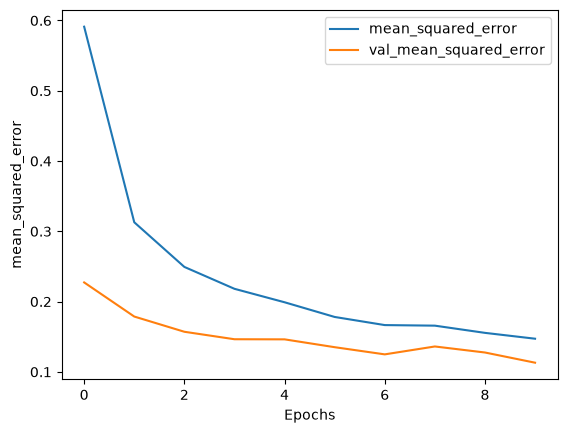

In [401]:
def plot_history(history, key):
  plt.plot(history.history[key])
  plt.plot(history.history['val_'+key])
  plt.xlabel("Epochs")
  plt.ylabel(key)
  plt.legend([key, 'val_'+key])
  plt.show()
# Plot the history
plot_history(history, 'mean_squared_error')

336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 211us/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 198us/step


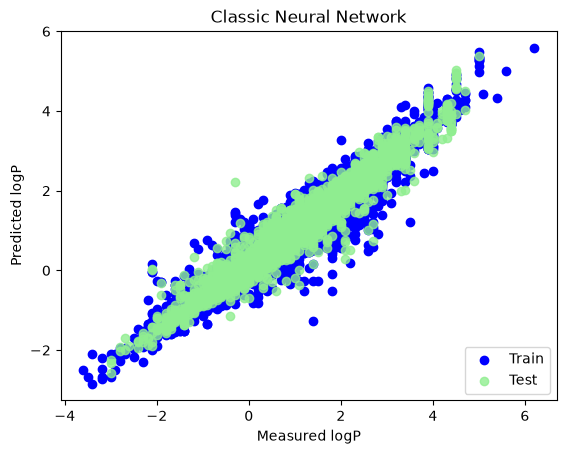

In [402]:
plt.scatter(y_train,model.predict(X_train), label = 'Train', c='blue')
plt.title('Classic Neural Network')
plt.xlabel('Measured logP')
plt.ylabel('Predicted logP')
plt.scatter(y_test,model.predict(X_test),c='lightgreen', label='Test', alpha = 0.8)
plt.legend(loc=4)
plt.show()

In [403]:
preds = model.predict(X_test)

print(model.predict(X_test[:5]))
print(y_test[:5])

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 199us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
[[-0.3154983 ]
 [ 2.0539303 ]
 [-1.101409  ]
 [ 1.0333819 ]
 [-0.02786119]]
[-0.6  2.3 -1.4  0.8  0.1]


In [404]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)
print(f'mse: {mse}, r2_score: {r2} ')

mse: 0.10964133248540912, r2_score: 0.9338619169528151 


Scikeras is needed for tuning

# Tuning the model

In [405]:
'''
Hyperparameter tuning
'''
from scikeras.wrappers import KerasRegressor

#KerasRegressor is needed as a wrapper as RandomSearch cannot read a normal neural network.

#First we build a function to build the model
def buildModel(neurons, first_activation, second_activation, third_activation):
    # Initialising the ANN
    model = Sequential([
    Dense(neurons, activation=first_activation, input_shape=(len(X_train[0]),)),
    Dropout(0.2),
    Dense(neurons, activation=second_activation),
    Dropout(0.2),
    Dense(1, activation=third_activation)
  ])
    
    # Compiling the ANN
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])
    
    return model


In [406]:
from sklearn.model_selection import RandomizedSearchCV 

#
regressor = KerasRegressor(model = buildModel, verbose=0)

parameters = {
    'batch_size': [64, 96, 128],
    'epochs': [5,10,15],
    'optimizer': ['adam'],
    'model__first_activation': ['relu','linear'],
    'model__second_activation': ['relu','linear'],
    'model__third_activation': ['linear'],
    'model__neurons': [32, 64, 128]
    
    }
random_search = RandomizedSearchCV(estimator = regressor,
                           param_distributions = parameters,
                           scoring = 'neg_mean_squared_error',
                           cv = 5,
                           verbose=0)
                           
random_results = random_search.fit(X_train, y_train)

/Users/xianliangchu/Desktop/CM4044 Mini Project II Group 8/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/xianliangchu/Desktop/CM4044 Mini Project II Group 8/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/xianliangchu/Desktop/CM4044 Mini Project II Group 8/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential m

In [407]:
random_results.best_params_


{'optimizer': 'adam',
 'model__third_activation': 'linear',
 'model__second_activation': 'relu',
 'model__neurons': 128,
 'model__first_activation': 'linear',
 'epochs': 10,
 'batch_size': 96}

In [408]:
random_results.best_score_

np.float64(-0.09390312903092568)

# Using the Optimized classic Neural Network

In [409]:
#optimized classic NN model

optimized_model = Sequential([
    Dense(128, activation='linear', input_shape=(len(X_train[0]),)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear') #final output has to be linear to accomodate negative values
  ])

  
optimized_model.compile(
    loss='mean_squared_error', 
    optimizer='SGD', 
    metrics=['mean_squared_error']
)
# train the model
history_optimized = optimized_model.fit(
    X_train,
    y_train,
    epochs=15, 
    batch_size=64,
)

Epoch 1/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 448us/step - loss: 0.4495 - mean_squared_error: 0.4495
Epoch 2/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - loss: 0.2782 - mean_squared_error: 0.2782
Epoch 3/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 427us/step - loss: 0.2324 - mean_squared_error: 0.2324
Epoch 4/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step - loss: 0.2109 - mean_squared_error: 0.2109
Epoch 5/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 417us/step - loss: 0.1969 - mean_squared_error: 0.1969
Epoch 6/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step - loss: 0.1886 - mean_squared_error: 0.1886
Epoch 7/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - loss: 0.1855 - mean_squared_error: 0.1855
Epoch 8/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step - loss: 0.1793 - mean_squared_error: 0.1793
Epoch 9/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step - loss: 0.1745 - mean_squared_error: 0.1745
Epoch 10/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step - loss: 0.1691 - mean_squared_error: 0.1691
Epoch 11/15
168/168

336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 216us/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 203us/step


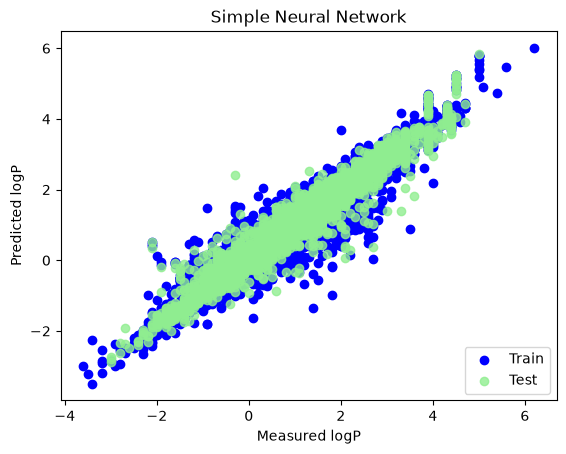

In [410]:
plt.scatter(y_train,optimized_model.predict(X_train), label = 'Train', c='blue')
plt.title('Simple Neural Network')
plt.xlabel('Measured logP')
plt.ylabel('Predicted logP')
plt.scatter(y_test,optimized_model.predict(X_test),c='lightgreen', label='Test', alpha = 0.8)
plt.legend(loc=4)
plt.show()

In [411]:
mse = mean_squared_error(y_test, optimized_model.predict(X_test))
r2 = r2_score(y_test, optimized_model.predict(X_test))
print(f'mse: {mse}, r2_score: {r2} ')

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 209us/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 209us/step
mse: 0.11052010659219437, r2_score: 0.9333318209248229 


In [412]:
print("Predicted: ")
print(optimized_model.predict(X_test[:10]))
print("'Actual: ")
print(y_test[:10])

Predicted: 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
[[-0.53136396]
 [ 2.1317225 ]
 [-1.3855333 ]
 [ 1.025456  ]
 [-0.13873476]
 [ 2.0168364 ]
 [ 1.9644624 ]
 [ 2.7345595 ]
 [-0.1831106 ]
 [ 1.3594095 ]]
'Actual: 
[-0.6  2.3 -1.4  0.8  0.1  2.1  2.   2.9 -0.2  1.1]


# Trying out RBFNN 

The RBFNN is written as a custom layer, and then added to the model.

In [413]:
#implementing rbf neural network
#RBFNN is has to be written customly because keras doesn't support it

from keras.layers import Layer
from keras import ops as K

# source: https://www.kaggle.com/code/residentmario/radial-basis-networks-and-custom-keras-layers

#Creating the custom RBFLayer

class RBFLayer(Layer):
    def __init__(self, units, gamma, **kwargs):
        super(RBFLayer, self).__init__(**kwargs)
        self.units = units
        self.gamma = float(gamma)

    def build(self, input_shape):
        self.mu = self.add_weight(name='mu',
                                  shape=(int(input_shape[1]), self.units),
                                  initializer='uniform',
                                  trainable=True)
        super(RBFLayer, self).build(input_shape)

    def call(self, inputs):
        diff = K.expand_dims(inputs, axis=-1) - self.mu        
        l2 = K.sum(K.power(diff, 2), axis=1)
        res = K.exp(-1 * self.gamma * l2)
        return res

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.units)

Take note that the model is almost the same as the one in the classic NN, only the second layer is the RBFLayer instead of a Dense layer

In [414]:


rbf = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='linear'),
    Dropout(0.2),
    RBFLayer(15, 0.5),
    Dropout(0.2),
    Dense(1, activation='linear')
  ])

rbf.compile(
    loss='mean_squared_error', 
    optimizer='adam', 
    metrics=['mean_squared_error']
)

history_rnn = rbf.fit(
    X_train,
    y_train,
    epochs=20, 
    batch_size=64,
)

Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 543us/step - loss: 2.5001 - mean_squared_error: 2.5001
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - loss: 1.5972 - mean_squared_error: 1.5972
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - loss: 0.7429 - mean_squared_error: 0.7429
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - loss: 0.6495 - mean_squared_error: 0.6495
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - loss: 0.5720 - mean_squared_error: 0.5720
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - loss: 0.5314 - mean_squared_error: 0.5314
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 685us/step - loss: 0.4890 - mean_squared_error: 0.4890
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 0.4527 - mean_squared_error: 0.4527
Epoch 9/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step - loss: 0.4279 - mean_squared_error: 0.4279
Epoch 10/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - loss: 0.3933 - mean_squared_error: 0.3933
Epoch 11/20
168/168

336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 250us/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 221us/step


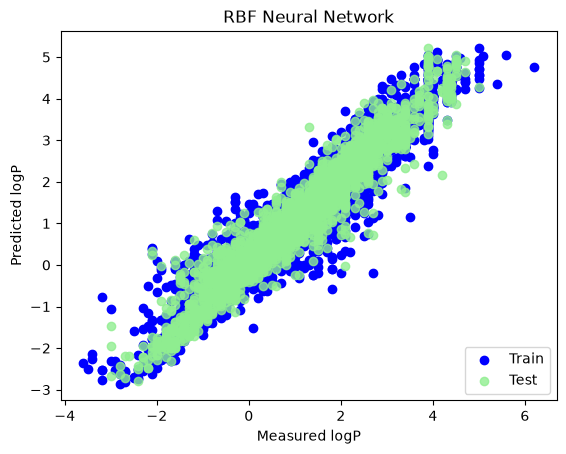

In [415]:
plt.scatter(y_train,rbf.predict(X_train), label = 'Train', c='blue')
plt.title('RBF Neural Network')
plt.xlabel('Measured logP')
plt.ylabel('Predicted logP')
plt.scatter(y_test,rbf.predict(X_test),c='lightgreen', label='Test', alpha = 0.8)
plt.legend(loc=4)
plt.show()

In [416]:
mse = mean_squared_error(y_test, rbf.predict(X_test))
r2 = r2_score(y_test, rbf.predict(X_test))
print(f'mse: {mse}, r2_score: {r2} ')

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 227us/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 220us/step
mse: 0.1374659630984104, r2_score: 0.9170774827570265 
